## **Handling Outliers using the IQR Method**

### Topic Roadmap


**1. Imports**

**2. Dataset Loading & Exploration**

**3. Data Visualization (Identifying Skewness)**

**4. Calculating IQR and Boundaries**

**5. Detecting Outliers**

**6. Strategy 1: Trimming**

**7. Strategy 2: Capping (Winsorization)**

**8. Key Revision Notes**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [ ]:
# Load dataset
df = pd.read_csv('docs/Lecture-029-placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


### **3. Data Visualization (Identifying Skewness)**

The IQR method is ideal for **skewed distributions**. We visualize the data using both a histogram and a boxplot to confirm the presence of outliers and skewness[cite: 9].

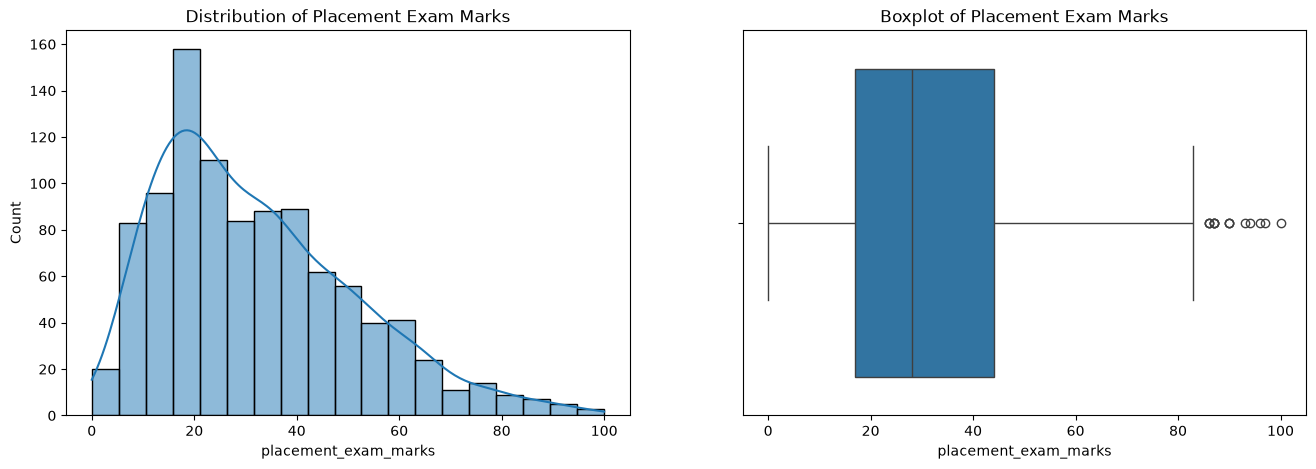

In [3]:
plt.figure(figsize=(16, 5))

# Histogram to show skewness
plt.subplot(1, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')

# Boxplot to clearly show outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Boxplot of Placement Exam Marks')

plt.show()

### **4. Calculating IQR and Boundaries**

The Interquartile Range (IQR) represents the middle 50% of the data. We use the 25th (Q1) and 75th (Q3) percentiles to establish lower and upper limits

In [4]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

# Calculate Interquartile Range (IQR)
iqr = percentile75 - percentile25

# Define upper and lower limits (1.5 * IQR rule)
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print("Upper limit:", upper_limit)
print("Lower limit:", lower_limit)

Upper limit: 84.5
Lower limit: -23.5


### **5. Detecting Outliers**

Identify rows where the values strictly exceed the upper limit or fall below the lower limit

In [5]:
# Displaying the outliers
outliers = df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks'] < lower_limit)]
outliers

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


### **6. Strategy 1: Trimming**

Trimming simply removes outlier rows from the dataset. Always use `.copy()` to avoid altering your source dataframe

In [6]:
# Apply trimming logic to a fresh copy
df_trimmed = df.copy()
df_trimmed = df_trimmed[(df_trimmed['placement_exam_marks'] <= upper_limit) & (df_trimmed['placement_exam_marks'] >= lower_limit)]

print("Original shape:", df.shape)
print("Trimmed shape:", df_trimmed.shape)

Original shape: (1000, 3)
Trimmed shape: (985, 3)


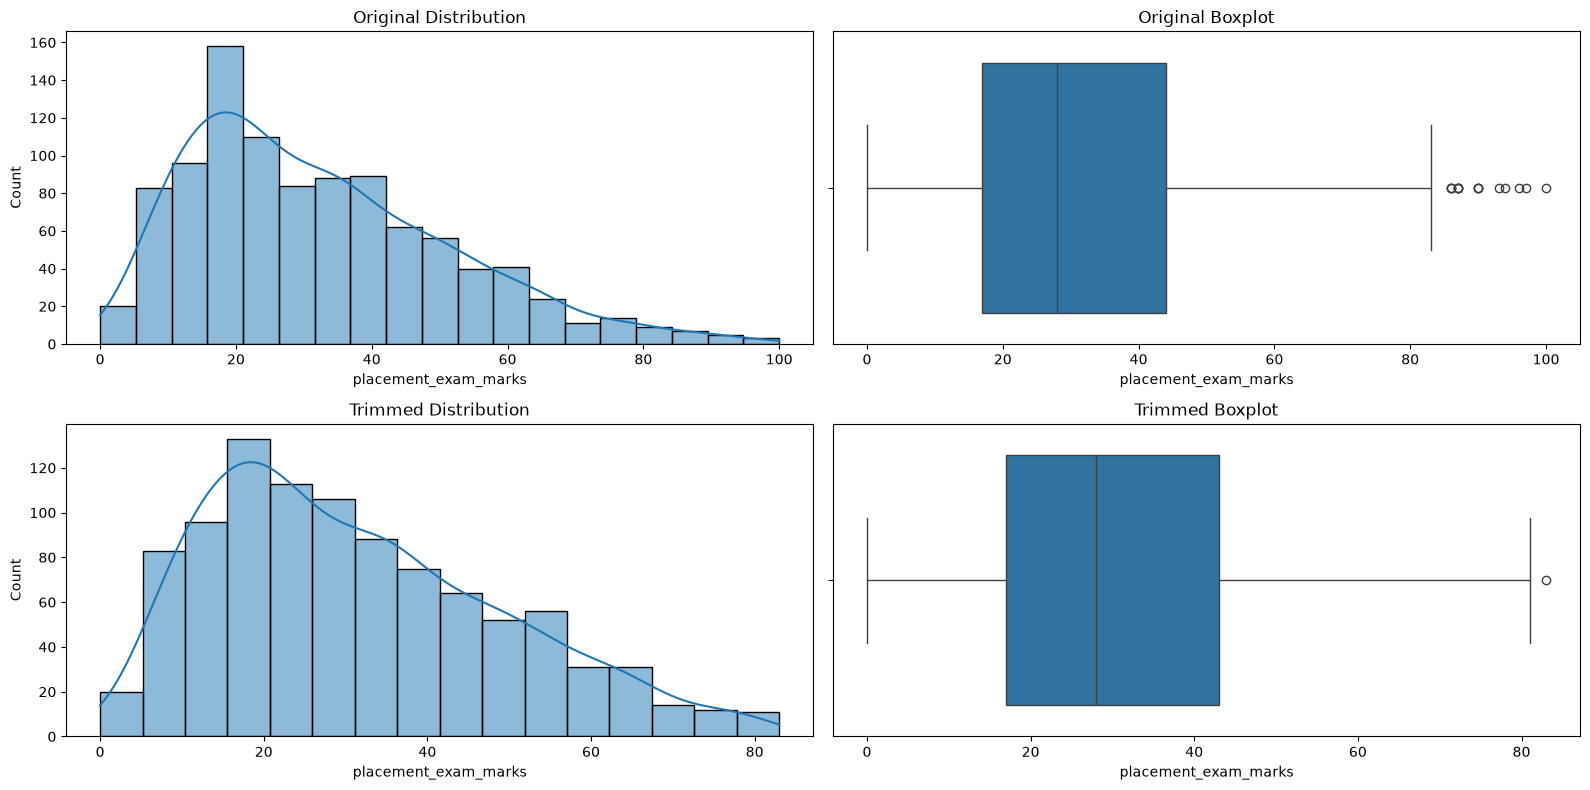

In [7]:
# Visual comparison for Trimming
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Original Distribution')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Original Boxplot')

plt.subplot(2, 2, 3)
sns.histplot(df_trimmed['placement_exam_marks'], kde=True)
plt.title('Trimmed Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(x=df_trimmed['placement_exam_marks'])
plt.title('Trimmed Boxplot')

plt.tight_layout()
plt.show()

### **7. Strategy 2: Capping (Winsorization)**

Capping modifies outlier values by shrinking them down (or up) to the calculated boundary limits, preventing data loss

In [8]:
df_capped = df.copy()

# Apply nested np.where to cap values
df_capped['placement_exam_marks'] = np.where(
    df_capped['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        df_capped['placement_exam_marks'] < lower_limit,
        lower_limit,
        df_capped['placement_exam_marks']
    )
)

print("Capped shape:", df_capped.shape) # Notice the row count remains identical to the original

Capped shape: (1000, 3)


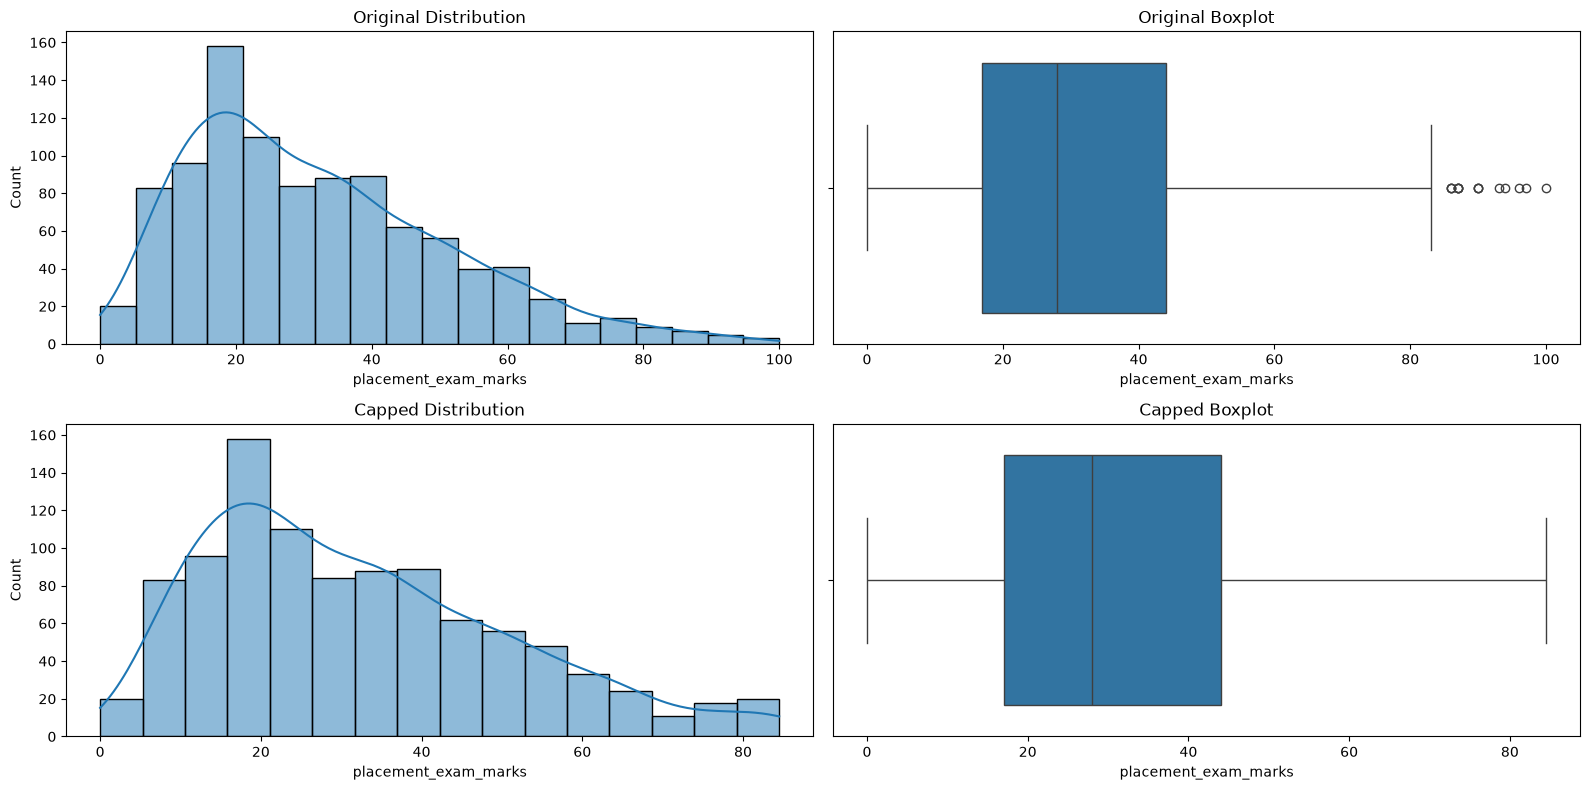

In [9]:
# Visual comparison for Capping
plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Original Distribution')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Original Boxplot')

plt.subplot(2, 2, 3)
sns.histplot(df_capped['placement_exam_marks'], kde=True)
plt.title('Capped Distribution')

plt.subplot(2, 2, 4)
sns.boxplot(x=df_capped['placement_exam_marks'])
plt.title('Capped Boxplot')

plt.tight_layout()
plt.show()

### **8. Key Revision Notes**

- **When to use IQR:** Use the IQR (Interquartile Range) proximity rule specifically when dealing with **skewed distributions**. If the data is perfectly normal, the Z-Score method is preferred.
- **Boundary Formulation:**
  - **Q1:** `df.quantile(0.25)`
  - **Q3:** `df.quantile(0.75)`
  - **IQR:** `Q3 - Q1`
  - **Limits:** `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`
- **Trimming:** Drops offending rows completely. Quick, but leads to data loss if outliers are abundant.
- **Capping:** Replaces offending values with the exact upper or lower limit. Preserves dataset size and shape, utilizing `np.where(condition, true_value, false_value)` logic.